**Importar los modulos necesarios**

In [1]:
import tensorflow as tf 
import tensorflow_datasets as tfds 

**Cargar el conjunto de datos MNIST**



*   Shuffle_files = True: mezcla los datos durante el entrenamiento, en particular para conjunto grande de datos
*   as_supervised = True: Devuelve una estructura (img, label)



In [ ]:
 (ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Dl Completed...:   0%|          | 0/4 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to ~/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [ ]:
tfds.as_dataframe(ds_train.take(4), ds_info)

,image,label
0,,4
1,,1
2,,0
3,,7


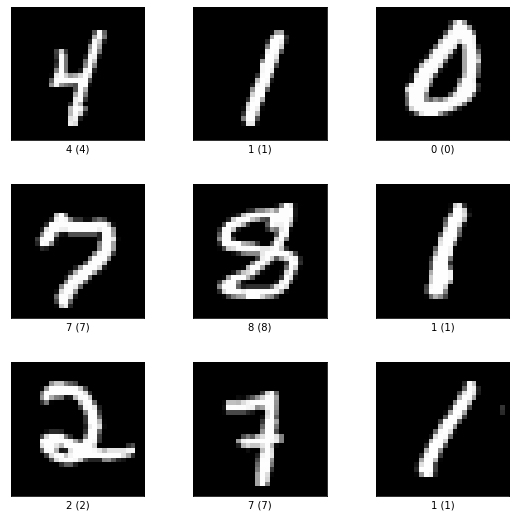

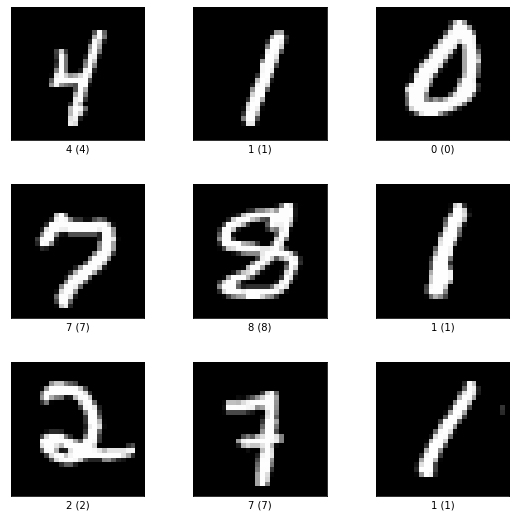

In [ ]:
tfds.show_examples(ds_train,ds_info)

In [ ]:
def normalize_img(image, label):
  """Normalizes images: `uint8` -> `float32`."""
  return tf.cast(image, tf.float32) / 255., label

ds_train = ds_train.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples)
ds_train = ds_train.batch(128)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

In [ ]:
ds_test = ds_test.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

In [ ]:
ds_train

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10)
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)

history = model.fit(
    ds_train,
    epochs=30,
    validation_data=ds_test,
)

Epoch 1/30
469/469 [==============================] - 8s 6ms/step - loss: 0.3652 - sparse_categorical_accuracy: 0.8983 - val_loss: 0.1986 - val_sparse_categorical_accuracy: 0.9433
Epoch 2/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1708 - sparse_categorical_accuracy: 0.9516 - val_loss: 0.1387 - val_sparse_categorical_accuracy: 0.9595
Epoch 3/30
469/469 [==============================] - 2s 4ms/step - loss: 0.1224 - sparse_categorical_accuracy: 0.9648 - val_loss: 0.1154 - val_sparse_categorical_accuracy: 0.9655
Epoch 4/30
469/469 [==============================] - 2s 4ms/step - loss: 0.0958 - sparse_categorical_accuracy: 0.9728 - val_loss: 0.1006 - val_sparse_categorical_accuracy: 0.9709
Epoch 5/30
469/469 [==============================] - 2s 4ms/step - loss: 0.0763 - sparse_categorical_accuracy: 0.9774 - val_loss: 0.0909 - val_sparse_categorical_accuracy: 0.9720
Epoch 6/30
469/469 [==============================] - 2s 4ms/step - loss: 0.0637 - sparse_categorica

In [ ]:
import matplotlib.pyplot as plt

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])


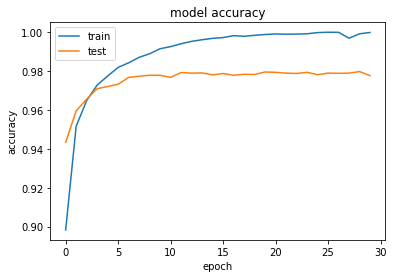

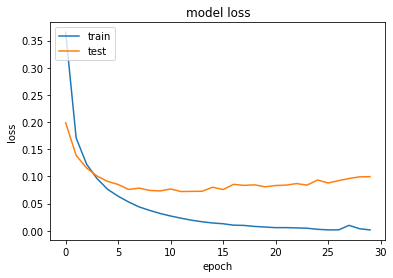

In [ ]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:

model_cnn = tf.keras.models.Sequential()
model_cnn.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28,28, 1)))
#16 es el numero de filtros, (3,3) es la dimension del filtro, input shape 28x28 pixeles con 1 color
model_cnn.add(tf.keras.layers.MaxPooling2D((2, 2)))
#Reduccion de imagenes
model_cnn.add(tf.keras.layers.Flatten())
#POnemos los datos en una linea
model_cnn.add(tf.keras.layers.Dense(32, activation='relu'))
model_cnn.add(tf.keras.layers.Dense(10))


model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)

history = model_cnn.fit(
    ds_train,
    epochs=30,
    validation_data=ds_test,
)

Epoch 1/30
469/469 [==============================] - 25s 52ms/step - loss: 0.3363 - sparse_categorical_accuracy: 0.9062 - val_loss: 0.1441 - val_sparse_categorical_accuracy: 0.9572
Epoch 2/30
469/469 [==============================] - 17s 35ms/step - loss: 0.1131 - sparse_categorical_accuracy: 0.9673 - val_loss: 0.0898 - val_sparse_categorical_accuracy: 0.9711
Epoch 3/30
469/469 [==============================] - 17s 35ms/step - loss: 0.0789 - sparse_categorical_accuracy: 0.9765 - val_loss: 0.0688 - val_sparse_categorical_accuracy: 0.9773
Epoch 4/30
469/469 [==============================] - 16s 35ms/step - loss: 0.0610 - sparse_categorical_accuracy: 0.9819 - val_loss: 0.0644 - val_sparse_categorical_accuracy: 0.9790
Epoch 5/30
469/469 [==============================] - 17s 37ms/step - loss: 0.0509 - sparse_categorical_accuracy: 0.9847 - val_loss: 0.0582 - val_sparse_categorical_accuracy: 0.9821
Epoch 6/30
469/469 [==============================] - 16s 35ms/step - loss: 0.0441 - spars

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])


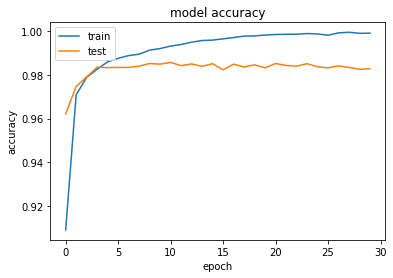

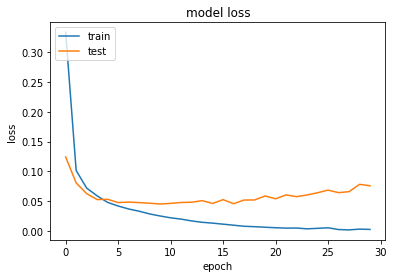

In [ ]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()